In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('Toronto Island Ferry Tickets.csv')

In [3]:
df.head()

,_id,Timestamp,Redemption Count,Sales Count
0,1,2025-12-21T22:30:00,14,16
1,2,2025-12-21T22:15:00,1,0
2,3,2025-12-21T22:00:00,2,0
3,4,2025-12-21T21:30:00,11,1
4,5,2025-12-21T21:15:00,10,0


In [4]:
df.shape

(261538, 4)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 261538 entries, 0 to 261537
Data columns (total 4 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   _id               261538 non-null  int64 
 1   Timestamp         261538 non-null  object
 2   Redemption Count  261538 non-null  int64 
 3   Sales Count       261538 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 8.0+ MB


In [6]:
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

In [7]:
df.isnull().sum()

_id                 0
Timestamp           0
Redemption Count    0
Sales Count         0
dtype: int64

In [8]:
df

,_id,Timestamp,Redemption Count,Sales Count
0,1,2025-12-21 22:30:00,14,16
1,2,2025-12-21 22:15:00,1,0
2,3,2025-12-21 22:00:00,2,0
3,4,2025-12-21 21:30:00,11,1
4,5,2025-12-21 21:15:00,10,0
...,...,...,...,...
261533,261534,2015-05-04 16:00:00,0,2
261534,261535,2015-05-01 16:00:00,1,0
261535,261536,2015-05-01 15:45:00,0,1
261536,261537,2015-05-01 15:15:00,0,2


In [9]:
num_duplicates=df.duplicated().sum()
print(f"Number of duplicate rows: {num_duplicates}")

Number of duplicate rows: 0


In [10]:
df = df.sort_index()
df_15min = df.resample('15min', on='Timestamp').sum()
df_hourly = df.resample('h', on='Timestamp').sum()
df_daily = df.resample('d', on='Timestamp').sum()

In [11]:
df_15min
df_hourly
df_daily

,_id,Redemption Count,Sales Count
Timestamp,,,
2015-05-01,1046146,1,4
2015-05-02,0,0,0
2015-05-03,0,0,0
2015-05-04,4968975,12,75
2015-05-05,12028655,537,549
...,...,...,...
2025-12-17,18528,658,463
2025-12-18,14817,783,550
2025-12-19,10461,581,387


In [12]:
df['Smoothed_Activity'] = df['Redemption Count'] + df['Sales Count']
df['Smoothed_Activity_Rolling'] = df['Smoothed_Activity'].rolling(window=4, center=True).mean()

In [13]:
df

,_id,Timestamp,Redemption Count,Sales Count,Smoothed_Activity,Smoothed_Activity_Rolling
0,1,2025-12-21 22:30:00,14,16,30,NaN
1,2,2025-12-21 22:15:00,1,0,1,NaN
2,3,2025-12-21 22:00:00,2,0,2,11.25
3,4,2025-12-21 21:30:00,11,1,12,6.25
4,5,2025-12-21 21:15:00,10,0,10,6.75
...,...,...,...,...,...,...
261533,261534,2015-05-04 16:00:00,0,2,2,2.00
261534,261535,2015-05-01 16:00:00,1,0,1,1.50
261535,261536,2015-05-01 15:45:00,0,1,1,1.50
261536,261537,2015-05-01 15:15:00,0,2,2,1.25


In [14]:
df['Total_Activity_Load'] = df['Redemption Count'] + df['Sales Count']
df['Redemption_Pressure_Ratio'] = df['Redemption Count'] / (df['Sales Count'] + 1)
min_load = df['Total_Activity_Load'].min()
max_load = df['Total_Activity_Load'].max()
df['OLI'] = (df['Total_Activity_Load'] - min_load) / (max_load - min_load)

In [15]:
df['Is_Low_Activity'] = df['Total_Activity_Load'] < 5
df['Idle_Capacity_Indicator'] = (df['Is_Low_Activity']
                                 .rolling(window=3)
                                 .apply(lambda x: x.all(), raw=True)
                                 .fillna(0)
                                 .astype(bool))

In [16]:
df['Year'] = df['Timestamp'].dt.year
df['Month'] = df['Timestamp'].dt.month
df['DayOfWeek'] = df['Timestamp'].dt.dayofweek # Monday=0, Sunday=6
df['Hour'] = df['Timestamp'].dt.hour
# Weekday vs Weekend
df['Is_Weekend'] = df['DayOfWeek'].isin([5, 6])

# Seasonal (Summer: June-August)
df['Season'] = df['Month'].apply(lambda x: 'Summer' if x in [6, 7, 8] else 'Off-Season')

# Time of Day Bands
def get_time_band(hour):
    if 5 <= hour < 12: return 'Morning'
    elif 12 <= hour < 17: return 'Afternoon'
    elif 17 <= hour < 22: return 'Evening'
    else: return 'Night'
df['Time_Band'] = df['Hour'].apply(get_time_band)

In [17]:
oli_90th = df['OLI'].quantile(0.9)
df['Is_Peak'] = df['OLI'] >= oli_90th

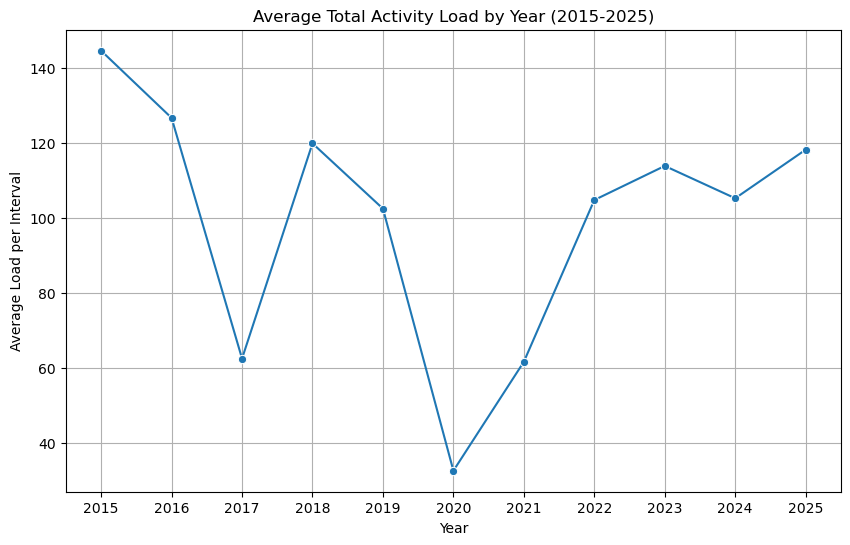

In [27]:
plt.figure(figsize=(10, 6))
sns.lineplot(data=df.groupby('Year')['Total_Activity_Load'].mean().reset_index(), 
             x='Year', y='Total_Activity_Load', marker='o')
years = np.arange(2015,2026)
plt.xticks(ticks=years, labels=years, fontsize=10)
plt.title('Average Total Activity Load by Year (2015-2025)')
plt.ylabel('Average Load per Interval')
plt.grid(True)
plt.show()

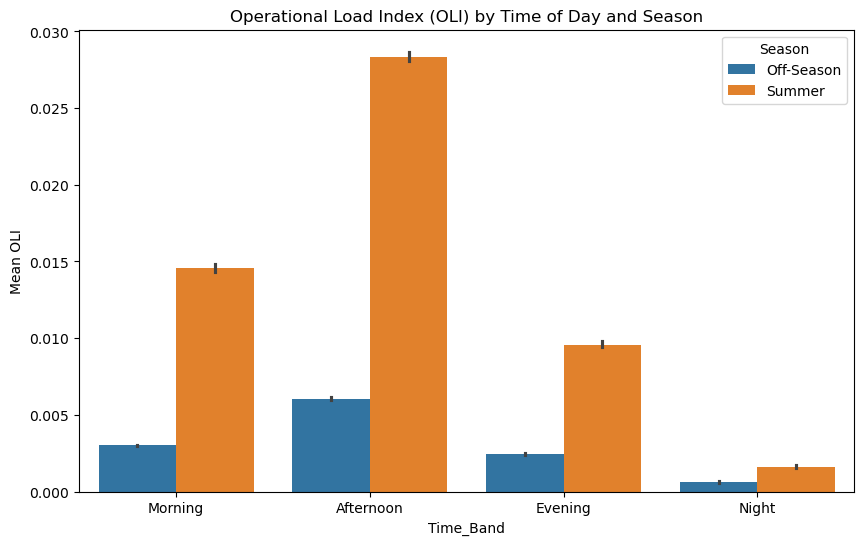

In [19]:
plt.figure(figsize=(10, 6))
sns.barplot(data=df, x='Time_Band', y='OLI', hue='Season', 
            order=['Morning', 'Afternoon', 'Evening', 'Night'])
plt.title('Operational Load Index (OLI) by Time of Day and Season')
plt.ylabel('Mean OLI')
plt.show()

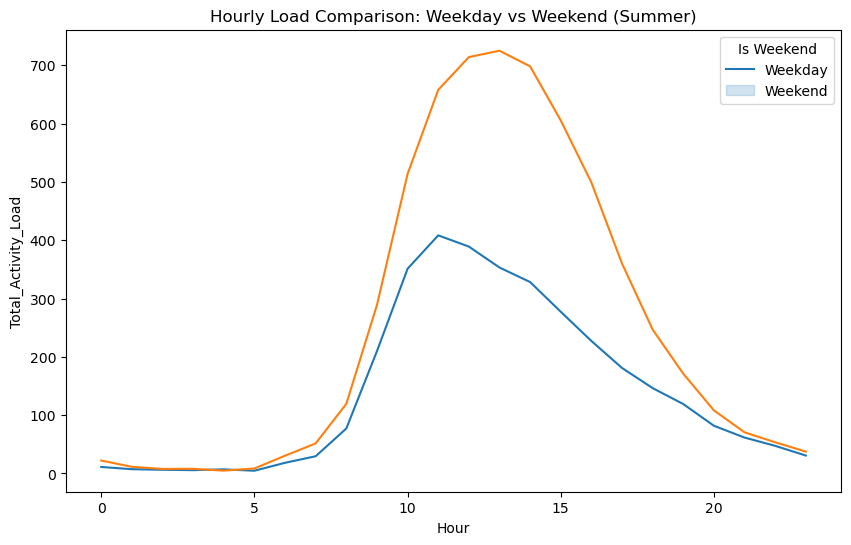

In [20]:
summer_df = df[df['Season'] == 'Summer']
plt.figure(figsize=(10, 6))
sns.lineplot(data=summer_df.groupby(['Hour', 'Is_Weekend'])['Total_Activity_Load'].mean().reset_index(), 
             x='Hour', y='Total_Activity_Load', hue='Is_Weekend')
plt.title('Hourly Load Comparison: Weekday vs Weekend (Summer)')
plt.legend(title='Is Weekend', labels=['Weekday', 'Weekend'])
plt.show()

In [23]:
df.head()

,_id,Timestamp,Redemption Count,Sales Count,Smoothed_Activity,Smoothed_Activity_Rolling,Total_Activity_Load,Redemption_Pressure_Ratio,OLI,Is_Low_Activity,Idle_Capacity_Indicator,Year,Month,DayOfWeek,Hour,Is_Weekend,Season,Time_Band,Is_Peak
0,1,2025-12-21 22:30:00,14,16,30,NaN,30,0.823529,0.002008,False,False,2025,12,6,22,True,Off-Season,Night,False
1,2,2025-12-21 22:15:00,1,0,1,NaN,1,1.000000,0.000000,True,False,2025,12,6,22,True,Off-Season,Night,False
2,3,2025-12-21 22:00:00,2,0,2,11.25,2,2.000000,0.000069,True,False,2025,12,6,22,True,Off-Season,Night,False
3,4,2025-12-21 21:30:00,11,1,12,6.25,12,5.500000,0.000762,False,False,2025,12,6,21,True,Off-Season,Evening,False
4,5,2025-12-21 21:15:00,10,0,10,6.75,10,10.000000,0.000623,False,False,2025,12,6,21,True,Off-Season,Evening,False


In [21]:
df.columns

Index(['_id', 'Timestamp', 'Redemption Count', 'Sales Count',
       'Smoothed_Activity', 'Smoothed_Activity_Rolling', 'Total_Activity_Load',
       'Redemption_Pressure_Ratio', 'OLI', 'Is_Low_Activity',
       'Idle_Capacity_Indicator', 'Year', 'Month', 'DayOfWeek', 'Hour',
       'Is_Weekend', 'Season', 'Time_Band', 'Is_Peak'],
      dtype='object')

In [22]:
df.to_csv('Processed_Ferry_Tickets.csv', index=False)